In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

# Path to your DEM file
dem_path = "/workspaces/swe-pinn/data/benchmark_test_1/test1DEM.asc"

def read_asc_file(filepath):
    header = {}
    with open(filepath, 'r') as f:
        # Read the first 6 lines (Header)
        for _ in range(6):
            line = f.readline().split()
            header[line[0].lower()] = float(line[1])
            
    # Read the data block (skipping header)
    # The data usually starts from top-left (North-West)
    dem_data = np.loadtxt(filepath, skiprows=6)
    return header, dem_data

header, dem_numpy = read_asc_file(dem_path)

# Extract key parameters
xll = header['xllcorner']
yll = header['yllcorner']
cellsize = header['cellsize']
nrows = int(header['nrows'])
ncols = int(header['ncols'])
nodata = header.get('nodata_value', -9999)

# Convert to JAX array (Move to GPU/TPU if available)
dem_jax = jnp.array(dem_numpy)

print(f"Loaded DEM with shape: {dem_jax.shape}")
print(f"Domain: X[{xll}, {xll + ncols*cellsize}], Y[{yll}, {yll + nrows*cellsize}]")

Loaded DEM with shape: (71, 371)
Domain: X[-20.0, 722.0], Y[-20.0, 122.0]


In [2]:
# 1. Define the interpolation function for a SINGLE point (x, y)
def get_elevation(x, y):
    """
    Input: Physical x, y coordinates (scalars)
    Output: Interpolated z value (scalar)
    """
    # Map physical x to column index (0 to ncols-1)
    # col = (x - x_start) / cell_size
    col_idx = (x - xll) / cellsize
    
    # Map physical y to row index.
    # IMPORTANT: Array row 0 is usually the TOP (Max Y).
    # So as Y increases, the row index should DECREASE.
    y_max = yll + nrows * cellsize
    row_idx = (y_max - y) / cellsize
    
    # We stack them as [row, col] for map_coordinates
    coords = jnp.array([row_idx, col_idx])
    
    # Perform interpolation
    # order=1 is linear (bilinear), order=3 is cubic (bicubic)
    # mode='nearest' handles points slightly outside the boundary safely
    z = jax.scipy.ndimage.map_coordinates(dem_jax, coords, order=1, mode='nearest')
    return z

# 2. Use JAX transformation to get gradients automatically
# grad(func, argnums=(0, 1)) returns derivatives w.r.t first and second arguments (x, y)
get_gradients = grad(get_elevation, argnums=(0, 1))

# 3. Combine them into one fast, JIT-compiled function
@jit
def bathymetry_fn_point(x, y):
    z = get_elevation(x, y)
    dz_dx, dz_dy = get_gradients(x, y)
    return z, dz_dx, dz_dy

# 4. Vectorize it so we can pass arrays of X and Y later
bathymetry_fn = vmap(bathymetry_fn_point)

print("Bathymetry functions compiled successfully.")

Bathymetry functions compiled successfully.


In [9]:
# Create dummy sample points (e.g., 10 random points inside the domain)
N_samples = 700
x_samples = jnp.linspace(xll + 10, xll + ncols*cellsize - 10, N_samples) # stay slightly inside
y_samples = jnp.linspace(yll + 10, yll + nrows*cellsize - 10, N_samples)

# --- RUN THE INTERPOLATOR ---
# This is where the magic happens. 
# Input: Vectors of X and Y
# Output: Vectors of Z, dZ/dX, dZ/dY
z_vals, dz_dx_vals, dz_dy_vals = bathymetry_fn(x_samples, y_samples)

# Display results
print(f"Shape of gradients: {dz_dx_vals.shape}")
print("\nSample Results:")
for i in range(-5, 0): # Print last 5
    print(f"Point ({x_samples[i]:.2f}, {y_samples[i]:.2f}) -> "
          f"Elev: {z_vals[i]:.4f}, Slope X: {dz_dx_vals[i]:.6f}, Slope Y: {dz_dy_vals[i]:.6f}")

# You can now use dz_dx_vals and dz_dy_vals in your physics loss!

Shape of gradients: (700,)

Sample Results:
Point (707.87, 111.30) -> Elev: 10.4236, Slope X: 0.003900, Slope Y: -0.000000
Point (708.90, 111.48) -> Elev: 10.4277, Slope X: 0.003950, Slope Y: -0.000000
Point (709.93, 111.65) -> Elev: 10.4317, Slope X: 0.003951, Slope Y: -0.000000
Point (710.97, 111.83) -> Elev: 10.4358, Slope X: 0.003900, Slope Y: -0.000000
Point (712.00, 112.00) -> Elev: 10.4398, Slope X: 0.003950, Slope Y: -0.000000


In [12]:
# --- CELL 2: Load DEM and Create Differentiable Interpolator ---

# 1. Define File Path (Adjust if needed)
dem_path = "/workspaces/swe-pinn/data/benchmark_test_1/test1DEM.asc"

# 2. Function to read the ESRI ASCII file
def read_asc_file(filepath):
    header = {}
    with open(filepath, 'r') as f:
        # Read Header
        for _ in range(6):
            line = f.readline().split()
            header[line[0].lower()] = float(line[1])
            
    # Read Data (flip vertically because row 0 is usually Y_max)
    dem_data = np.loadtxt(filepath, skiprows=6)
    return header, dem_data

# 3. Load Data
try:
    header, dem_numpy = read_asc_file(dem_path)
    print("DEM Loaded Successfully.")
except FileNotFoundError:
    print(f"Error: Could not find file at {dem_path}")
    # Create dummy data for demonstration if file is missing
    header = {'xllcorner': 0, 'yllcorner': 0, 'cellsize': 2, 'nrows': 50, 'ncols': 350}
    dem_numpy = np.zeros((50, 350)) 

# 4. Prepare JAX Arrays
dem_jax = jnp.array(dem_numpy, dtype=DTYPE)
xll = header['xllcorner']
yll = header['yllcorner']
cellsize = header['cellsize']
nrows = int(header['nrows'])
ncols = int(header['ncols'])

# 5. Define the Interpolator (The "Continuous Space" Logic)
def get_elevation_scalar(x, y):
    # Map physical (x, y) to grid indices (col, row)
    col_idx = (x - xll) / cellsize
    # Note: row index 0 is at Y_max, so we invert Y
    y_max = yll + nrows * cellsize
    row_idx = (y_max - y) / cellsize
    
    coords = jnp.array([row_idx, col_idx])
    
    # Bilinear interpolation (order=1)
    return jax.scipy.ndimage.map_coordinates(dem_jax, coords, order=1, mode='nearest')

# 6. Create Gradient Functions using Automatic Differentiation
grad_z = grad(get_elevation_scalar, argnums=(0, 1)) # dZ/dX, dZ/dY

@jit
def get_bathymetry_at_point(x, y):
    z = get_elevation_scalar(x, y)
    dz_dx, dz_dy = grad_z(x, y)
    return z, dz_dx, dz_dy

# Vectorize to handle batches of points
get_bathymetry_batch = vmap(get_bathymetry_at_point)

print(f"Interpolator ready. Domain Size: {ncols*cellsize}m x {nrows*cellsize}m")

DEM Loaded Successfully.
Interpolator ready. Domain Size: 742.0m x 142.0m


Sampling 700 random points...

--- Test Results ---
Input Batch Shape: (700, 3)
Gradient Vector Shapes: dz/dx=(700,), dz/dy=(700,)

First 5 Sample Points:
X (m)      | Y (m)      | Elev (m)   | dz/dx      | dz/dy     
-----------------------------------------------------------------
219.82     | 99.70      | 10.1168    | 0.002100   | -0.000000 
246.13     | 87.70      | 10.1729    | 0.002150   | -0.000000 
523.72     | 69.24      | 9.7672     | 0.001400   | -0.000000 
499.04     | 41.88      | 9.7500     | -0.000050  | -0.000000 
202.51     | 35.55      | 10.0800    | 0.002150   | -0.000000 


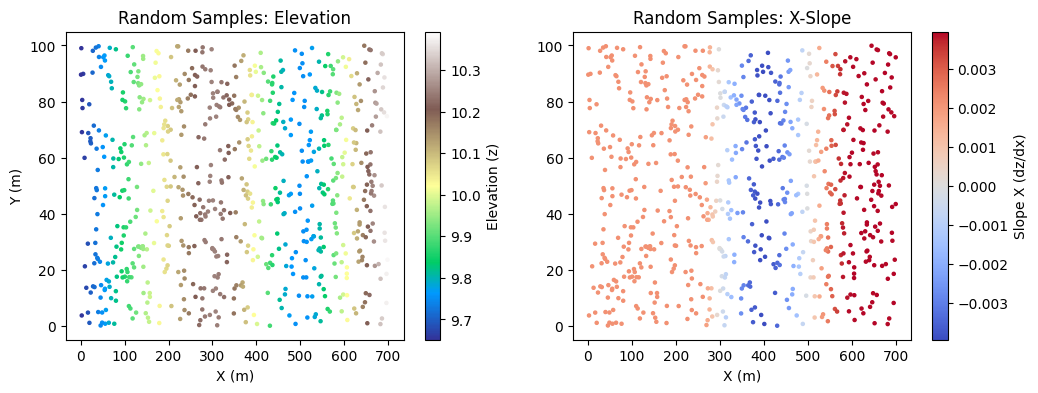

In [14]:
# --- CELL 3: Test Random Sampling Strategy ---

# 1. Define Bounds for Test 1
# Domain is 700m x 100m, Time is 20 hours
x_bounds = (0.0, 700.0)
y_bounds = (0.0, 100.0)
t_bounds = (0.0, 20.0 * 3600) # Convert hours to seconds if needed

# 2. Number of random points to sample
N_samples = 700 
key = random.PRNGKey(1234)

# 3. USE YOUR SRC.DATA FUNCTION
# This generates the random (x, y, t) batch
print(f"Sampling {N_samples} random points...")
batch_points = sample_domain(key, N_samples, x_bounds, y_bounds, t_bounds)

# 4. Extract Coordinates
# batch_points shape is (N, 3) -> [x, y, t]
x_batch = batch_points[:, 0]
y_batch = batch_points[:, 1]

# 5. Calculate Gradients (The "Vector" you asked for)
# This turns your random discontinuous points into continuous gradients
z_vec, dz_dx_vec, dz_dy_vec = get_bathymetry_batch(x_batch, y_batch)

# --- CELL 4: Verify Results ---

print("\n--- Test Results ---")
print(f"Input Batch Shape: {batch_points.shape}")
print(f"Gradient Vector Shapes: dz/dx={dz_dx_vec.shape}, dz/dy={dz_dy_vec.shape}")

# Sanity Check: Print first 5 points
print("\nFirst 5 Sample Points:")
print(f"{'X (m)':<10} | {'Y (m)':<10} | {'Elev (m)':<10} | {'dz/dx':<10} | {'dz/dy':<10}")
print("-" * 65)
for i in range(5):
    print(f"{x_batch[i]:<10.2f} | {y_batch[i]:<10.2f} | {z_vec[i]:<10.4f} | {dz_dx_vec[i]:<10.6f} | {dz_dy_vec[i]:<10.6f}")

# Visualization Check
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(x_batch, y_batch, c=z_vec, cmap='terrain', s=5)
plt.colorbar(label='Elevation (z)')
plt.title("Random Samples: Elevation")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")

plt.subplot(1, 2, 2)
plt.scatter(x_batch, y_batch, c=dz_dx_vec, cmap='coolwarm', s=5)
plt.colorbar(label='Slope X (dz/dx)')
plt.title("Random Samples: X-Slope")
plt.xlabel("X (m)")
plt.show()

In [16]:
import pandas as pd
import jax.numpy as jnp

def load_boundary_condition(filepath):
	"""
	Loads boundary condition data from CSV and returns a JAX-compatible interpolation function.
	Assumes CSV format: Column 0 = Time (s), Column 1 = Value (e.g., Water Level).
	"""
	df = pd.read_csv(filepath)
	# Convert to JAX arrays (float32 for GPU compatibility)
	t_vals = jnp.array(df.iloc[:, 0].values, dtype=jnp.float32)
	bc_vals = jnp.array(df.iloc[:, 1].values, dtype=jnp.float32)

	# Define interpolation function
	def bc_interpolator(t):
		return jnp.interp(t, t_vals, bc_vals)
		
	return bc_interpolator

bc_fn = load_boundary_condition("/workspaces/swe-pinn/data/benchmark_test_1/Test1BC.csv")

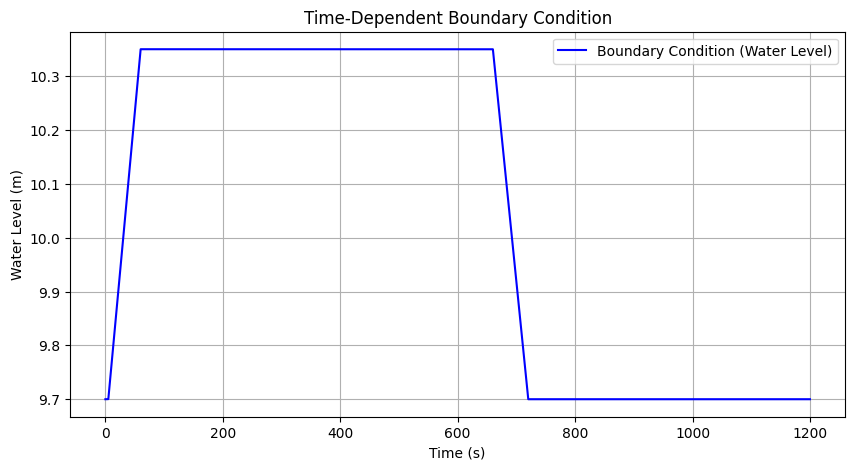

In [26]:
import matplotlib.pyplot as plt

# Generate time values for plotting (from 0 to 120,000 seconds)
t_plot = jnp.linspace(0, 1200, 1200*60)

# Evaluate the boundary condition function at these time points
# jax.vmap is used to vectorize the function over the array of time points
bc_values = vmap(bc_fn)(t_plot)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t_plot, bc_values, label='Boundary Condition (Water Level)', color='blue')
plt.xlabel('Time (s)')
plt.ylabel('Water Level (m)')
plt.title('Time-Dependent Boundary Condition')
plt.grid(True)
plt.legend()
plt.show()

Loaded data shape: (144002, 6)
Found 2 unique gauge locations.
Processing Gauge 1: x=395.8723, y=49.6465
Processing Gauge 2: x=604.3547, y=50.5657


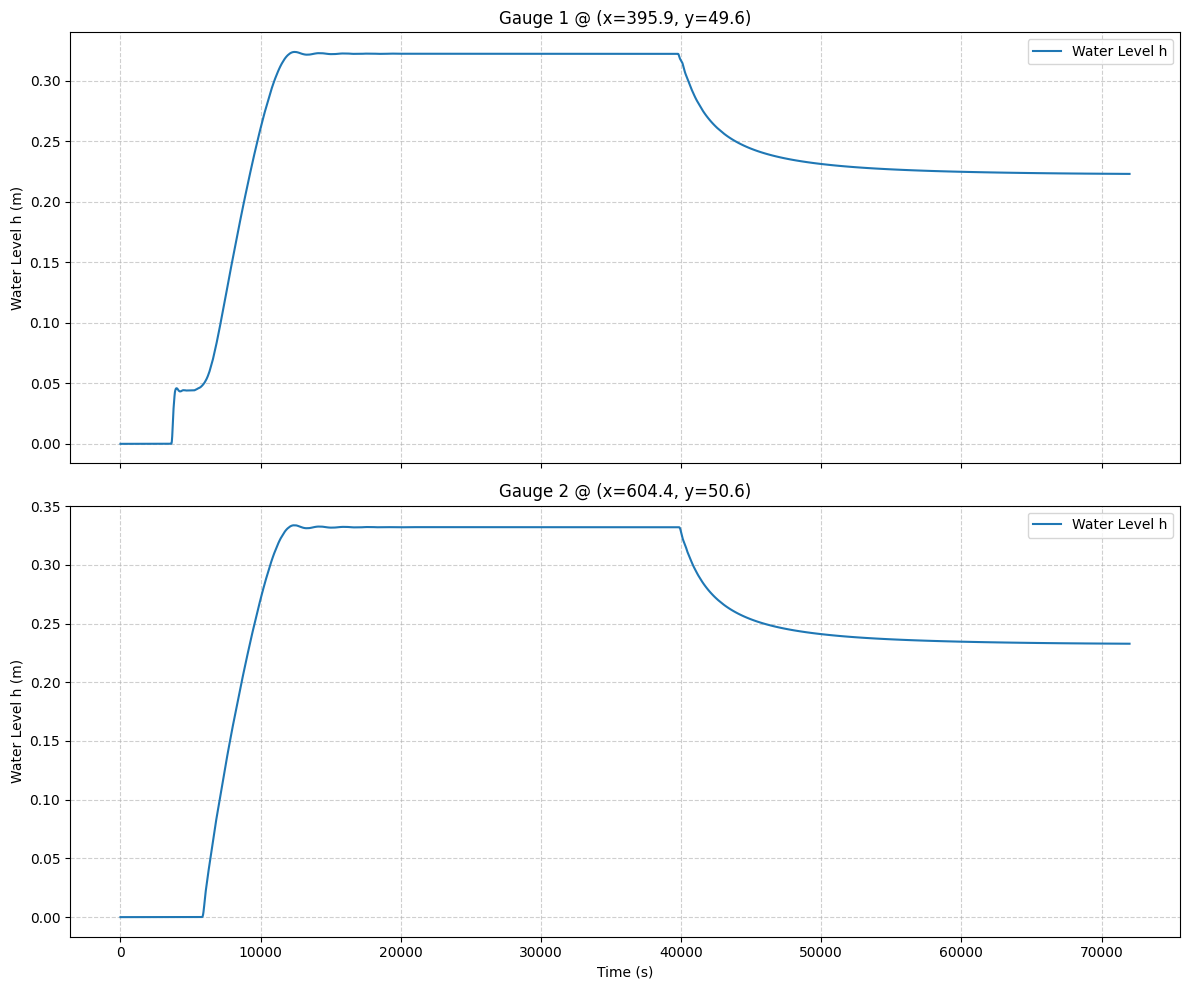

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
data_path = '/workspaces/swe-pinn/data/benchmark_test_1/validation_gauges.npy'
data = np.load(data_path)

print(f"Loaded data shape: {data.shape}")  # Expected columns: [t, x, y, h, u, v]

# 2. Identify Unique (x, y) locations dynamically
# Extract x and y columns
xy_coords = data[:, 1:3]
# Find unique rows (coordinate pairs)
unique_locs = np.unique(xy_coords, axis=0)

print(f"Found {len(unique_locs)} unique gauge locations.")

# 3. Plot h vs t for each unique location
fig, axs = plt.subplots(len(unique_locs), 1, figsize=(12, 5 * len(unique_locs)), sharex=True)

# Handle case where there is only 1 gauge (subplots returns axes object, not array)
if len(unique_locs) == 1:
    axs = [axs]

for i, (x_loc, y_loc) in enumerate(unique_locs):
    print(f"Processing Gauge {i+1}: x={x_loc:.4f}, y={y_loc:.4f}")
    
    # Extract data for this location using float comparison safety
    mask = np.isclose(data[:, 1], x_loc) & np.isclose(data[:, 2], y_loc)
    loc_data = data[mask]
    
    # Sort by time (column 0)
    loc_data = loc_data[loc_data[:, 0].argsort()]
    
    # Plot h (column 3) vs t (column 0)
    axs[i].plot(loc_data[:, 0], loc_data[:, 3], label=f'Water Level h')
    axs[i].set_ylabel('Water Level h (m)')
    axs[i].set_title(f'Gauge {i+1} @ (x={x_loc:.1f}, y={y_loc:.1f})')
    axs[i].grid(True, linestyle='--', alpha=0.6)
    axs[i].legend()

axs[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

# 1. Load Data
data_path = '/workspaces/swe-pinn/data/benchmark_test_1/validation_gauges.npy'
data = np.load(data_path)

print(f"Data shape: {data.shape}")  # Expected: (144002, 6)
print(data)

Data shape: (144002, 6)
[[ 0.0000000e+00  6.0435474e+02  5.0565735e+01  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  3.9587225e+02  4.9646515e+01  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 1.0000000e+00  6.0435474e+02  5.0565735e+01  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 7.1999000e+04  3.9587225e+02  4.9646515e+01  2.2289000e-01
  -1.8102670e-05  8.5025486e-06]
 [ 7.2000000e+04  6.0435474e+02  5.0565735e+01  2.3278999e-01
  -1.9695461e-05 -3.4768973e-06]
 [ 7.2000000e+04  3.9587225e+02  4.9646515e+01  2.2289000e-01
  -1.8098246e-05  8.5119609e-06]]
